# Breaking RSA with Shor's Algorithm — An Interactive Walkthrough

This notebook tells **one story in three chapters**:

> Quantum computers *can* break the encryption that protects the internet — but **not yet** — so the rational response is to migrate to quantum-proof ("post-quantum") cryptography *now*, before the hardware catches up.

| Chapter | Script | Proves | One word |
|---|---|---|---|
| 1 | `run_shor_local.py` | A quantum computer can find the secret factors of a number | **Weapon** |
| 2 | `run_rsa_break.py` | Those factors decrypt a real secret message | **Crime** |
| 3 | `run_shor_hardware.py` | Real hardware is still far too weak to do this for real | **Reality** |

We use the number **15** as a toy stand-in for a real ~617-digit RSA modulus. The algorithm is identical at both scales — only the number of qubits changes.

*Run the cells top to bottom. Everything except the hardware section runs on a local simulator (instant, offline, no credentials).*

## 0. Setup

Import the project's modules and plotting libraries. This notebook lives at the project root, so `from src...` imports resolve directly. Make sure you're running with the project's virtual environment (`.venv`) as the kernel.

In [8]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt

from src.shor import (
    N,
    VALID_BASES,
    candidate_period,
    factor,
    factors_from_period,
    measure_phases,
    order_finding_circuit,
)
from src.rsa_break import build_keypair, break_public_key, decrypt, encrypt

print(f"Target modulus N = {N}  (secretly {3} x {5})")
print(f"Valid bases coprime to {N}: {VALID_BASES}")

Target modulus N = 15  (secretly 3 x 5)
Valid bases coprime to 15: (2, 4, 7, 8, 11, 13)


## 1. Background: why factoring breaks RSA

RSA encryption — the math protecting most of the internet — is locked by a single public number `N` that is secretly the product of two large primes:

$$N = p \times q$$

It is *easy* to multiply `p` and `q` together, but *classically infeasible* to reverse it and recover `p` and `q` from a large `N`. That one-way difficulty is the entire foundation of RSA's security. Every secret in an RSA key can be reconstructed the moment you know `p` and `q`.

**Shor's algorithm** factors `N` efficiently on a quantum computer. It doesn't brute-force the factors — it finds the **period** of a repeating sequence, and that period hands you the factors.

## 2. Why the number 15?

`15` is the "Hello World" of quantum factoring: the smallest product of two distinct odd primes (`3 × 5`). It's also *deliberately* tiny because today's real hardware can barely factor it. The size gap to real encryption is staggering — run the next cell to see it.

In [9]:
scales = [
    ("This demo", 4, "15"),
    ("Real RSA today", 2048, "~617-digit number"),
    ("High-security RSA", 4096, "~1234-digit number"),
]
print(f"{'Use case':<20}{'Bits':>6}{'Decimal digits':>18}   Example")
print("-" * 70)
for name, bits, example in scales:
    digits = round(bits * math.log10(2))
    print(f"{name:<20}{bits:>6}{digits:>18}   {example}")

print()
print("Qubits needed to factor 15:           ~8        (today's machines have this)")
print("Qubits to factor a 2048-bit RSA key:  ~20,000,000 noisy physical qubits")
print("Best machines today:                  ~1,000 noisy qubits  ->  ~20,000x gap")

Use case              Bits    Decimal digits   Example
----------------------------------------------------------------------
This demo                4                 1   15
Real RSA today        2048               617   ~617-digit number
High-security RSA     4096              1233   ~1234-digit number

Qubits needed to factor 15:           ~8        (today's machines have this)
Qubits to factor a 2048-bit RSA key:  ~20,000,000 noisy physical qubits
Best machines today:                  ~1,000 noisy qubits  ->  ~20,000x gap


## 3. What is a "period"?

Pick a base `a` coprime to `N` (we use `a = 7`). Keep multiplying by `a` mod 15. The remainders **cycle**, and the length of that cycle is the **period** `r`:

$$r = \text{smallest } r > 0 \text{ such that } a^r \equiv 1 \pmod{N}$$

Run the next cell to watch `7^x mod 15` repeat.

In [10]:
a = 7
sequence = [pow(a, x, N) for x in range(9)]

print(f"x:        " + "  ".join(f"{x:2d}" for x in range(9)))
print(f"{a}^x mod {N}: " + "  ".join(f"{v:2d}" for v in sequence))

# The period is the first x > 0 where the value returns to 1.
r_classical = next(x for x in range(1, len(sequence)) if sequence[x] == 1)
print(f"\nThe sequence returns to 1 every {r_classical} steps  ->  period r = {r_classical}")
print(f"Check: {a}^{r_classical} mod {N} = {pow(a, r_classical, N)}")

x:         0   1   2   3   4   5   6   7   8
7^x mod 15:  1   7   4  13   1   7   4  13   1

The sequence returns to 1 every 4 steps  ->  period r = 4
Check: 7^4 mod 15 = 1


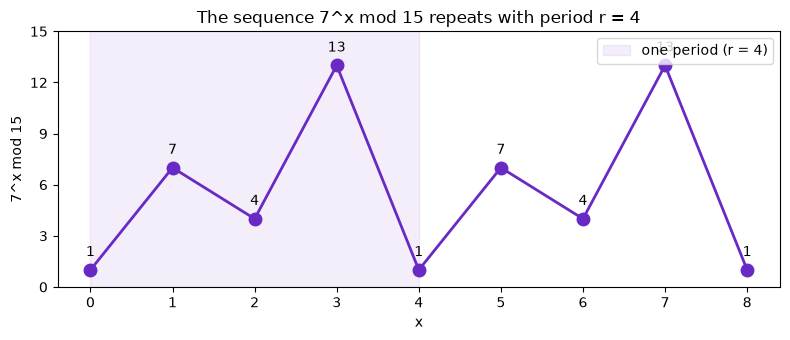

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(9), sequence, "o-", color="#6929c4", linewidth=2, markersize=9)
for x, v in enumerate(sequence):
    ax.annotate(str(v), (x, v), textcoords="offset points", xytext=(0, 10), ha="center")
# Shade one full period to make the repetition obvious.
ax.axvspan(0, r_classical, color="#6929c4", alpha=0.08, label=f"one period (r = {r_classical})")
ax.set_xlabel("x")
ax.set_ylabel(f"{a}^x mod {N}")
ax.set_title(f"The sequence {a}^x mod {N} repeats with period r = {r_classical}")
ax.set_yticks(range(0, 16, 3))
ax.legend()
plt.tight_layout()
plt.show()

## 4. File 1 — Quantum order finding (the *weapon*)

For `N = 15` you can read the period off a tiny table. But for a 617-digit number the cycle is astronomically long and classically infeasible to walk. A quantum computer finds `r` **without walking the cycle**:

1. Put *all* values of `x` into superposition at once.
2. Compute `a^x mod N` for all of them simultaneously (quantum parallelism).
3. Apply an **inverse Quantum Fourier Transform** — a "prism" that detects the repeat *frequency* of the cycle.
4. Measure: outcomes cluster at phases that are multiples of `1/r`.

The circuit below is exactly what `examples/run_shor_local.py` runs.

Circuit: 12 qubits, depth 11


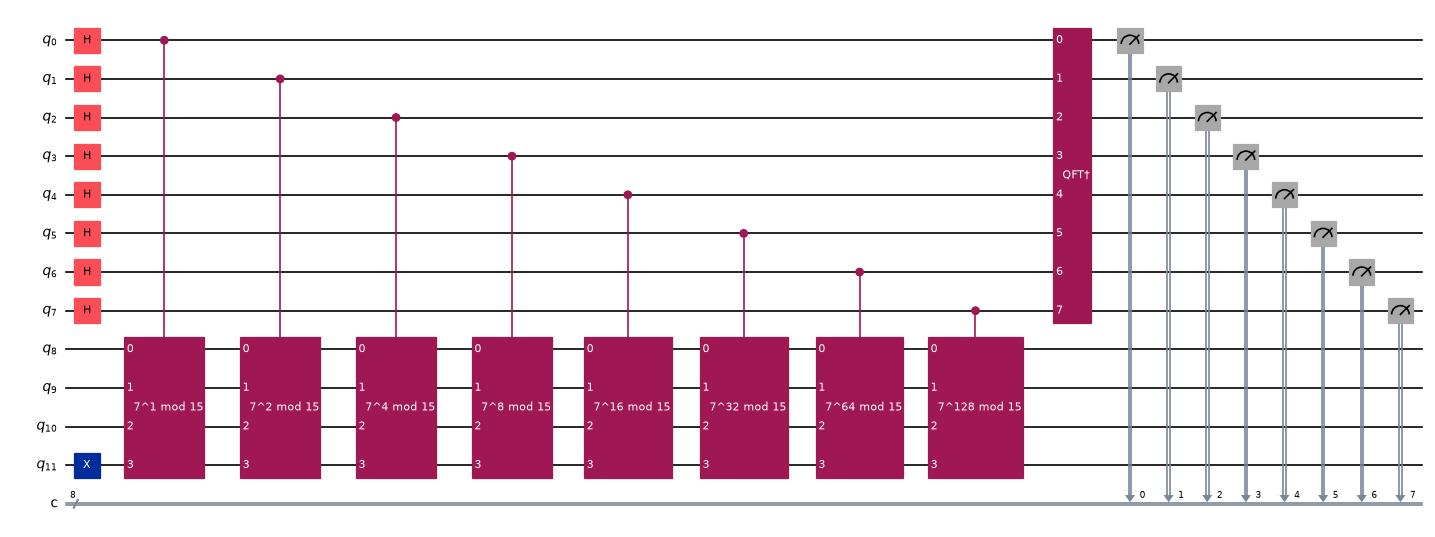

In [12]:
# Draw the order-finding circuit (8 counting qubits + 4 work qubits).
qc = order_finding_circuit(a=7, n_count=8)
print(f"Circuit: {qc.num_qubits} qubits, depth {qc.depth()}")
qc.draw("mpl", fold=-1, scale=0.6)

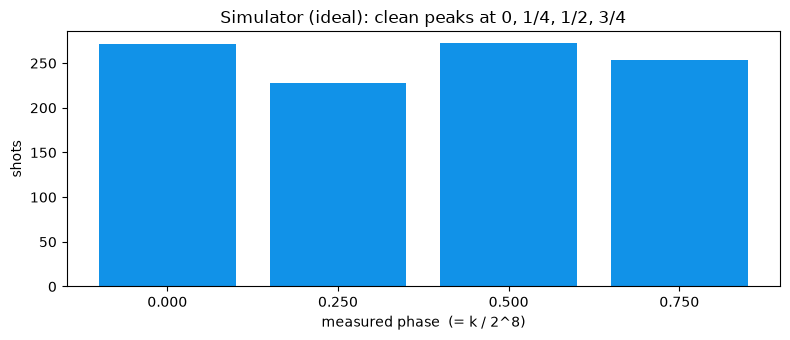

Phases (multiples of 1/4 -> period 4):
  phase 0.500  ->  1/2   (272 shots)
  phase 0.000  ->  0   (271 shots)
  phase 0.750  ->  3/4   (253 shots)
  phase 0.250  ->  1/4   (228 shots)


In [13]:
# Run order finding on the local simulator and look at the measured phases.
sim_phases = measure_phases(a=7, n_count=8, shots=1024)

# Keep the phases that actually got measured (sorted for plotting).
items = sorted(sim_phases.items())
labels = [f"{p:.3f}" for p, _ in items]
values = [c for _, c in items]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(labels, values, color="#1192e8")
ax.set_xlabel("measured phase  (= k / 2^8)")
ax.set_ylabel("shots")
ax.set_title("Simulator (ideal): clean peaks at 0, 1/4, 1/2, 3/4")
plt.tight_layout()
plt.show()

print("Phases (multiples of 1/4 -> period 4):")
for p, c in sorted(sim_phases.items(), key=lambda kv: -kv[1]):
    print(f"  phase {p:.3f}  ->  {Fraction(p).limit_denominator(15)}   ({c} shots)")

In [14]:
# The high-level factor() wraps all of the above into one call.
result = factor(a=7)
print(f"base a        = {result.a}")
print(f"period r      = {result.period}")
print(f"best phase    = {result.phase}")
print(f"method        = {result.method}")
print(f"factors found = {result.factors}")
assert result.factors is not None and result.factors[0] * result.factors[1] == N
print(f"\n>>> {N} = {result.factors[0]} x {result.factors[1]}  — the quantum lock-pick worked.")

base a        = 7
period r      = 4
best phase    = 0.25
method        = quantum
factors found = (3, 5)

>>> 15 = 3 x 5  — the quantum lock-pick worked.


## 5. From period to factors — the math

If `r` is even, then $a^r \equiv 1 \pmod N$ factors as:

$$\left(a^{r/2}-1\right)\left(a^{r/2}+1\right) \equiv 0 \pmod N$$

So each half shares a factor with `N`, recoverable with `gcd`. The next cell does it explicitly.

In [15]:
r = 4
half = pow(a, r // 2, N)          # 7^2 mod 15 = 4
print(f"a^(r/2) = {a}^{r // 2} mod {N} = {half}")
print(f"gcd({half} - 1, {N}) = gcd({half - 1}, {N}) = {math.gcd(half - 1, N)}")
print(f"gcd({half} + 1, {N}) = gcd({half + 1}, {N}) = {math.gcd(half + 1, N)}")
print(f"\nFactors: {math.gcd(half - 1, N)} and {math.gcd(half + 1, N)}")

a^(r/2) = 7^2 mod 15 = 4
gcd(4 - 1, 15) = gcd(3, 15) = 3
gcd(4 + 1, 15) = gcd(5, 15) = 5

Factors: 3 and 5


## 6. File 2 — Breaking RSA end to end (the *crime*)

Knowing the factors unlocks the whole chain:

$$r=4 \;\rightarrow\; \text{factors } 3,5 \;\rightarrow\; \varphi(N)=8 \;\rightarrow\; \text{private key } d \;\rightarrow\; \text{decrypt anything}$$

The attacker sees **only** the public key `(N, e)` and the ciphertext — never the private key. Watch them reconstruct it and steal the message. This is exactly `examples/run_rsa_break.py`.

In [16]:
# --- 1. Owner builds a keypair; only the public half is published. ---
key = build_keypair(p=3, q=5, e=7)
print(f"[owner]    public key (N, e) = {key.public_key}")
print(f"[owner]    PRIVATE key d = {key.d}  (kept secret, with primes 3 and 5)")

# --- 2. Someone encrypts a secret message with the public key. ---
secret = 2
ciphertext = encrypt(secret, key.public_key)
print(f"\n[sender]   secret m = {secret}  ->  ciphertext c = {ciphertext}")

# --- 3. Attacker has ONLY (N, e) and c. Runs Shor to recover d. ---
brk = break_public_key(key.public_key, seed=1)
print(f"\n[attacker] Shor period r = {brk.shor.period} (base {brk.shor.a})")
print(f"[attacker] factors {brk.factors}  ->  phi(N) = {brk.phi}  ->  recovered d = {brk.recovered_d}")

# --- 4. Decrypt with the stolen key. ---
cracked = decrypt(ciphertext, brk.recovered_d, key.public_key[0])
print(f"\n[attacker] decrypts c = {ciphertext}  ->  m = {cracked}")
print(f">>> {'MATCH — message stolen!' if cracked == secret else 'mismatch'}")

# It's a master key: every message round-trips.
all_ok = all(decrypt(encrypt(m, key.public_key), brk.recovered_d, N) == m for m in range(N))
print(f">>> stolen d decrypts EVERY message 0..{N - 1}: {all_ok}")

[owner]    public key (N, e) = (15, 7)
[owner]    PRIVATE key d = 7  (kept secret, with primes 3 and 5)

[sender]   secret m = 2  ->  ciphertext c = 8

[attacker] Shor period r = 2 (base 4)
[attacker] factors (3, 5)  ->  phi(N) = 8  ->  recovered d = 7

[attacker] decrypts c = 8  ->  m = 2
>>> MATCH — message stolen!
>>> stolen d decrypts EVERY message 0..14: True


> **Honest note on this toy:** for `N = 15` the math happens to force `d == e`. That's a quirk of this tiny modulus; at real key sizes `d ≠ e`. What matters is that `d` was *derived from the secret factors*, which are unobtainable without Shor.

## 7. File 3 — Real IBM hardware (the *reality check*)

Everything above ran on a perfect simulator. The next cell submits the **same** circuit to a real IBM quantum computer (`examples/run_shor_hardware.py`).

⚠️ **This consumes your IBM Quantum runtime quota and may sit in a queue.** It is guarded by `RUN_HARDWARE = False` so the notebook doesn't submit a job by accident. Set it to `True` only when you want to spend quota.

In [17]:
RUN_HARDWARE = False  # set True to spend quota and submit a real job

if RUN_HARDWARE:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    from src.quantum_service import get_service
    from src.shor import phases_from_counts

    service = get_service()
    backend = service.least_busy(operational=True, simulator=False)
    print(f"Using real backend: {backend.name}")

    hw_circuit = order_finding_circuit(a=7, n_count=3)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    isa = pm.run(hw_circuit)
    print(f"Transpiled depth: {isa.depth()} (abstract depth: {hw_circuit.depth()})")

    job = Sampler(mode=backend).run([isa], shots=1024)
    print(f"Submitted job {job.job_id()} — may queue...")
    hw_counts = job.result()[0].data.c.get_counts()
    hw_phases = phases_from_counts(hw_counts, 3)
    print("Hardware phases:", {round(p, 3): c for p, c in sorted(hw_phases.items())})
else:
    print("Skipped — RUN_HARDWARE is False. The next cell visualises a real recorded run.")

Skipped — RUN_HARDWARE is False. The next cell visualises a real recorded run.


## 8. Simulator vs. real hardware — what actually happened

The cell below plots a **real recorded run** on `ibm_fez` (3 counting qubits) next to the ideal simulator. The single most important number is the **circuit depth blowup**: an abstract depth of **6** becomes **~2,236** after transpiling to the chip's native gates and limited connectivity (long chains of SWAP gates). Each 2-qubit gate has ~1% error, and errors *multiply*:

$$\text{fidelity} \approx 0.99^{\text{(number of 2-qubit gates)}} \quad\Rightarrow\quad 0.99^{300} \approx 0.05$$

So by the end, almost no quantum signal survives — a fully decohered state collapses to the **maximally mixed state** (every outcome equally likely), which is why the hardware bars are nearly flat.

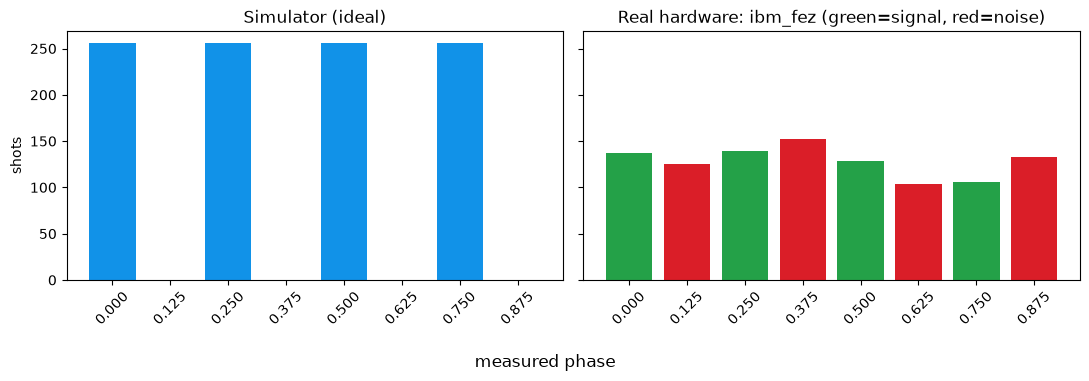

Abstract circuit depth:   6
Transpiled (hardware):    ~2236
Signal (0, 1/4, 1/2, 3/4): 510/1024 = 49.8%
Noise (everything else):   514/1024 = 50.2%

The signal barely clears 50% — the correct answer (r=4) is rescued
by the CLASSICAL post-processing, not by a clean quantum measurement.


In [18]:
# Real recorded data: ibm_fez, a=7, n_count=3, 1024 shots.
phases3 = [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875]
hw_recorded = [137, 125, 139, 152, 128, 104, 106, 133]
# Ideal: only the 4 "quarter" phases carry signal.
sim_ideal = [256, 0, 256, 0, 256, 0, 256, 0]

signal_phases = {0.0, 0.25, 0.5, 0.75}
signal = sum(c for p, c in zip(phases3, hw_recorded) if p in signal_phases)
noise = sum(hw_recorded) - signal
total = sum(hw_recorded)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = range(len(phases3))
labels = [f"{p:.3f}" for p in phases3]
axes[0].bar(x, sim_ideal, color="#1192e8")
axes[0].set_title("Simulator (ideal)")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("shots")
colors = ["#24a148" if p in signal_phases else "#da1e28" for p in phases3]
axes[1].bar(x, hw_recorded, color=colors)
axes[1].set_title("Real hardware: ibm_fez (green=signal, red=noise)")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=45)
fig.supxlabel("measured phase")
plt.tight_layout()
plt.show()

print(f"Abstract circuit depth:   6")
print(f"Transpiled (hardware):    ~2236")
print(f"Signal (0, 1/4, 1/2, 3/4): {signal}/{total} = {100*signal/total:.1f}%")
print(f"Noise (everything else):   {noise}/{total} = {100*noise/total:.1f}%")
print("\nThe signal barely clears 50% — the correct answer (r=4) is rescued")
print("by the CLASSICAL post-processing, not by a clean quantum measurement.")

## 9. Conclusion — why this argues for post-quantum cryptography

- **Files 1 + 2 (simulator):** the attack **absolutely works in principle** — find the period, factor `N`, rebuild the private key, decrypt everything.
- **File 3 (real chip):** today's hardware **can't pull it off** beyond toy numbers — noise swamps the signal even for `15`.
- **Therefore:** the danger is *coming, not here* — which is the entire reason to migrate to **post-quantum cryptography** *before* the machines get good enough.

This is the **"harvest-now, decrypt-later"** urgency: an attacker can record encrypted traffic *today* and decrypt it *years later* once a large fault-tolerant quantum computer exists. Long-lived secrets are exposed now even though the computer doesn't exist yet.

The NIST-standardized PQC algorithms — **ML-KEM** (key exchange), **ML-DSA** and **SLH-DSA** (signatures) — use lattice/hash math that Shor's algorithm cannot crack, and they run on ordinary classical computers.

---

**Further reading:** see [`docs/shor-rsa-demo.md`](docs/shor-rsa-demo.md) for the full prose walkthrough, and the runnable scripts in [`examples/`](examples/).

*Caveat throughout: these demos show the mechanism at toy scale. The modular-multiplication circuit is hand-compiled for `N = 15`. Breaking real RSA-2048 needs millions of error-corrected qubits that do not exist yet.*